# 01 · data ingestion

pull a big universe of us etfs from `financedatabase` (it also gives us each fund's category, so we
dont have to hit yahoo per-ticker just to group them), download daily OHLCV (price *and* volume) in
one pass, drop the dead ones, save to `data/raw/`.

change the exchanges / history length in `config.yaml`. `pip install financedatabase` if you dont have it.

saves three files: `prices.parquet` (close, used by 02/03/04), `market_data.parquet` (full OHLCV +
volume, used by 03's volume features), `metadata.parquet` (category / peer-group labels + quality
flags). one download feeds all three - no separate volume-only pull.

In [1]:
import yaml, pathlib, logging
import numpy as np, pandas as pd
import yfinance as yf
import financedatabase as fd
import matplotlib.pyplot as plt
pd.set_option('display.width', 200, 'display.max_columns', 30)
logging.getLogger('yfinance').setLevel(logging.CRITICAL)   # quiet the 'delisted' spam

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW = ROOT / cfg['paths']['raw']; RAW.mkdir(parents=True, exist_ok=True)
dcfg = cfg['data']

## build the universe

every etf on the exchanges we listed in config. financedatabase already carries name / category /
family so this is all local - no network yet.

In [2]:
etfs = fd.ETFs().data
uni = etfs[etfs['exchange'].isin(cfg['exchanges'])].copy()
uni.index = uni.index.astype(str).str.strip()
uni = uni[~uni.index.duplicated()]
tickers = sorted(uni.index.unique())
TICKERS=tickers
print(len(tickers), 'etfs across', uni['category'].nunique(), 'categories')
uni['category'].value_counts().head(12)

2150 etfs across 40 categories


category
Developed Markets    312
Emerging Markets     184
Large Cap            163
Corporate Bonds      133
Small Cap            130
Trading               92
Factors               83
Growth                72
Value                 67
Mid Cap               59
Blend                 56
High Yield Bonds      51
Name: count, dtype: int64

## download prices + volume

one batched pass over yahoo, full OHLCV. delisted / dead tickers just wont return anything and we
drop them. ~2k funds x 10y takes a few minutes.

In [3]:
def download_full_universe(tickers, period, interval, auto_adjust, batch=300):
    out = []
    for i in range(0, len(tickers), batch):
        b = tickers[i:i+batch]
        df = yf.download(b, period=period, interval=interval, auto_adjust=auto_adjust,
                         progress=False, group_by='column', threads=True)
        if df.empty:
            continue
            
        # If it's a single ticker batch, yf drops the MultiIndex. Let's force it back 
        # so everything concatenates cleanly along columns.
        if not isinstance(df.columns, pd.MultiIndex):
            df.columns = pd.MultiIndex.from_product([df.columns, b])
            
        out.append(df)
        print(f'  {min(i+batch, len(tickers)):>5}/{len(tickers)}')
        
    # Combine all batches
    full_df = pd.concat(out, axis=1)
    
    # Drop any duplicate columns across batches and sort dates
    full_df = full_df.loc[:, ~full_df.columns.duplicated()].sort_index()
    full_df.index.name = 'date'
    
    return full_df

# Run it
market_data = download_full_universe(tickers, dcfg['period'], dcfg['interval'], dcfg['auto_adjust'])
print('Downloaded raw data matrix:', market_data.shape)

    300/2150


    600/2150


    900/2150


   1200/2150


   1500/2150


   1800/2150


   2100/2150


   2150/2150


Downloaded raw data matrix: (2514, 10855)


In [4]:
prices = market_data.xs('Close', axis=1, level=0)
volume = market_data.xs('Volume', axis=1, level=0)
prices.index.name = 'date'; prices.columns.name = 'ticker'
volume.index.name = 'date'; volume.columns.name = 'ticker'

prices = prices.dropna(axis=1, how='all')
keep = prices.notna().sum() >= cfg['min_days']
prices = prices.loc[:, keep]
volume = volume.reindex(columns=prices.columns)
market_data = market_data.loc[:, market_data.columns.get_level_values(1).isin(prices.columns)]

print(prices.shape[1], 'funds kept (>=', cfg['min_days'], 'days) |',
      prices.index.min().date(), '->', prices.index.max().date())
prices.iloc[-3:, :6]

1975 funds kept (>= 252 days) | 2016-07-11 -> 2026-07-10


ticker,AAA,AAAU,AADR,AAXJ,ABCS,ABEQ
date,,,,,,
2026-07-08,25.010000,40.240002,83.089996,115.209999,33.716000,37.273998
2026-07-09,25.000000,40.639999,84.150002,116.290001,34.039001,37.270000
2026-07-10,24.950001,40.500000,84.190002,116.220001,34.161999,37.419998


## keep funds with enough history

anything with less than ~1y of data (config `min_days`) is too short to build 5d-ahead labels on.

## metadata + peer groups

straight from financedatabase - `category` is our peer group. no slow per-ticker yahoo calls.
(expense ratio / aum / holdings we can enrich later for a shortlist - too slow to pull for ~2k funds.)

In [5]:
meta_cols = ['name','category_group','category','family','currency','exchange']
metadata = uni.reindex(prices.columns)[meta_cols].copy()
metadata.index.name = 'ticker'
metadata['category'] = metadata['category'].fillna('Uncategorized')
metadata['category_group'] = metadata['category_group'].fillna('Uncategorized')

# flag leveraged / inverse etfs (2x/3x/inverse) by name - their returns arent comparable to
# normal peers so we can drop them later (config: exclude_leveraged).
nm = metadata['name'].fillna('').str.lower()
lev_kw = ['ultrapro','ultrashort','inverse','leveraged','proshares ultra','direxion daily',
          ' 2x',' 3x','-2x','-3x','-1x',' 1.5x',' 2.5x']
lev = nm.apply(lambda s: any(k in s for k in lev_kw)) | (metadata['category'] == 'Trading')
# but dont flag 'ultra-short duration' bond funds
bond_fp = (nm.str.contains('ultra-short') | nm.str.contains('ultra short'))
bond_fp &= ~nm.apply(lambda s: any(k in s for k in ['proshares','direxion',' 2x',' 3x','-3x','inverse']))
metadata['is_leveraged'] = lev & ~bond_fp

# flag broken price series - any absurd 1d move (data glitch / unadjusted split), e.g. TAAG
chg = prices.pct_change(fill_method=None).abs().max()
metadata['bad_ticks'] = (chg > cfg.get('max_daily_move', 0.5)).reindex(metadata.index).fillna(False)

# flag delisted / dead funds - price series stops well before the panel end (e.g. ACTV, delisted 2025)
gap = (prices.index.max() - prices.apply(lambda s: s.last_valid_index())).dt.days
metadata['is_delisted'] = (gap > 30).reindex(metadata.index).fillna(True)
print(metadata.shape, '|', int(metadata['is_leveraged'].sum()), 'leveraged,',
      int(metadata['bad_ticks'].sum()), 'bad-tick,', int(metadata['is_delisted'].sum()), 'delisted')
metadata.head()

(1975, 9) | 176 leveraged, 47 bad-tick, 345 delisted


,name,category_group,category,family,currency,exchange,is_leveraged,bad_ticks,is_delisted
ticker,,,,,,,,,
AAA,AAF First Priority CLO Bond ETF,Fixed Income,Corporate Bonds,Exchange Traded Concepts,USD,PCX,False,False,False
AAAU,Goldman Sachs Physical Gold ETF,Commodities,Uncategorized,Goldman Sachs Asset Management,USD,PCX,False,False,False
AADR,AdvisorShares Dorsey Wright ADR ETF,Financials,Emerging Markets,AdvisorShares,USD,NMS,False,False,False
AAXJ,iShares MSCI All Country Asia ex Japan ETF,Financials,Emerging Markets,BlackRock Asset Management,USD,NMS,False,False,False
ABCS,Guggenheim ABC High Dividend ET,Financials,Uncategorized,Guggenheim,NaN,PCX,False,False,False


In [6]:
# how many funds per category (this is what the label groups on)
sizes = metadata['category'].value_counts()
print(sizes.head(15))
print('\ncategories with <', cfg['labels']['min_group'], 'funds:', (sizes < cfg['labels']['min_group']).sum())

category
Developed Markets    302
Uncategorized        211
Emerging Markets     177
Large Cap            153
Corporate Bonds      125
Small Cap            116
Trading               92
Factors               77
Growth                68
Value                 61
Mid Cap               55
Blend                 51
High Yield Bonds      48
Treasury Bonds        47
Municipal Bonds       45
Name: count, dtype: int64

categories with < 3 funds: 3


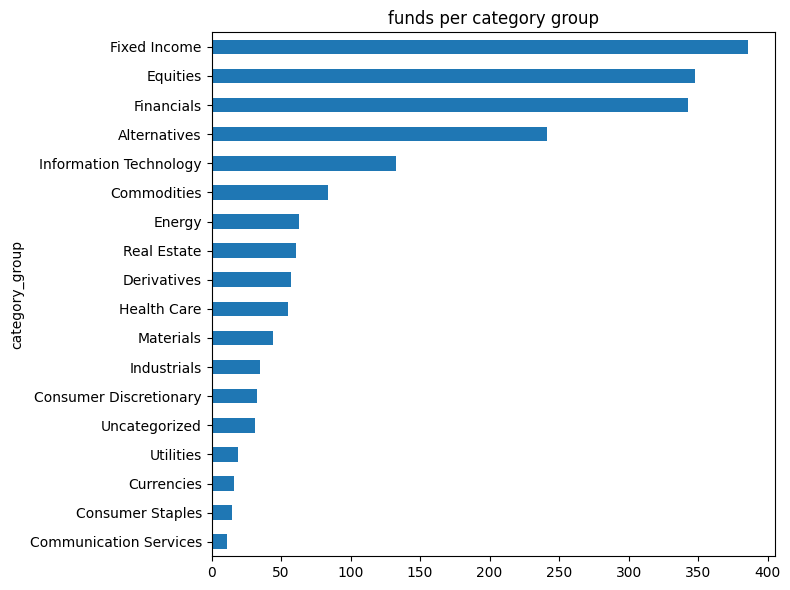

In [7]:
# funds per category_group - a scannable view of what the universe holds
ax = metadata['category_group'].value_counts().plot.barh(figsize=(8, 6))
ax.set_title('funds per category group'); ax.invert_yaxis(); plt.tight_layout(); plt.show()

## save

In [8]:
prices.to_parquet(RAW / 'prices.parquet');     prices.to_csv(RAW / 'prices.csv')
metadata.to_parquet(RAW / 'metadata.parquet'); metadata.to_csv(RAW / 'metadata.csv')
market_data.to_parquet(RAW / 'market_data.parquet'); market_data.to_csv(RAW / 'market_data.csv')
print('saved', prices.shape[1], 'funds (prices + volume + metadata) to', RAW)

saved 1975 funds (prices + volume + metadata) to C:\Users\user\Desktop\CS\overp\outperforming\data\raw


In [ ]:
import yfinance as yf
import pandas as pd
import os, json, time

def download_full_universe(tickers, period, interval, auto_adjust, batch=300):
    """Bulk OHLCV download — batched since yf.download supports multi-ticker calls."""
    out = []
    for i in range(0, len(tickers), batch):
        b = tickers[i:i+batch]
        df = yf.download(b, period=period, interval=interval, auto_adjust=auto_adjust,
                         progress=False, group_by='column', threads=True)
        if df.empty:
            continue
        if not isinstance(df.columns, pd.MultiIndex):
            df.columns = pd.MultiIndex.from_product([df.columns, b])
        out.append(df)
        print(f'  OHLCV {min(i+batch, len(tickers)):>5}/{len(tickers)}')

    full_df = pd.concat(out, axis=1)
    full_df = full_df.loc[:, ~full_df.columns.duplicated()].sort_index()
    full_df.index.name = 'date'
    return full_df


def safe_save_any(obj, path):
    if obj is None:
        return
    if isinstance(obj, pd.DataFrame):
        if not obj.empty:
            obj.to_csv(path)
    elif isinstance(obj, pd.Series):
        if not obj.empty:
            obj.to_frame().to_csv(path)
    elif isinstance(obj, (dict, list)):
        if obj:
            with open(path, "w") as f:
                json.dump(obj, f, indent=2, default=str)
    else:
        with open(path, "w") as f:
            f.write(str(obj))


def download_everything_else(tickers, out_dir="etf_data", sleep=1.0):
    """Per-ticker metadata/fundamentals — no batch API exists for these in yfinance."""
    os.makedirs(out_dir, exist_ok=True)

    for n, symbol in enumerate(tickers, 1):
        ticker_dir = os.path.join(out_dir, symbol)
        os.makedirs(ticker_dir, exist_ok=True)
        t = yf.Ticker(symbol)

        safe_save_any(t.dividends, f"{ticker_dir}/dividends.csv")
        safe_save_any(t.splits, f"{ticker_dir}/splits.csv")
        safe_save_any(t.capital_gains, f"{ticker_dir}/capital_gains.csv")
        safe_save_any(t.actions, f"{ticker_dir}/actions.csv")

        try:
            safe_save_any(t.info, f"{ticker_dir}/info.json")
        except Exception as e:
            print(f"  {symbol} info failed: {e}")

        try:
            safe_save_any(dict(t.fast_info), f"{ticker_dir}/fast_info.json")
        except Exception as e:
            print(f"  {symbol} fast_info failed: {e}")

        try:
            fd = t.funds_data
        except Exception as e:
            fd = None
            print(f"  {symbol} funds_data init failed: {e}")

        if fd is not None:
            for attr, ext in [
                ("description", "json"), ("top_holdings", "csv"),
                ("asset_classes", "json"), ("sector_weightings", "json"),
                ("equity_holdings", "json"), ("bond_holdings", "json"),
                ("bond_ratings", "json"), ("fund_overview", "json"),
                ("fund_operations", "json"),
            ]:
                try:
                    val = getattr(fd, attr, None)
                    safe_save_any(val, f"{ticker_dir}/{attr}.{ext}")
                except Exception as e:
                    print(f"  {symbol} funds_data.{attr} failed: {e}")

        try:
            safe_save_any(t.institutional_holders, f"{ticker_dir}/institutional_holders.csv")
            safe_save_any(t.mutualfund_holders, f"{ticker_dir}/mutualfund_holders.csv")
            safe_save_any(t.major_holders, f"{ticker_dir}/major_holders.csv")
        except Exception as e:
            print(f"  {symbol} holders failed: {e}")

        try:
            safe_save_any(t.news, f"{ticker_dir}/news.json")
        except Exception as e:
            print(f"  {symbol} news failed: {e}")

        try:
            shares = t.get_shares_full(period="max")
            safe_save_any(shares, f"{ticker_dir}/shares_outstanding.csv")
        except Exception as e:
            print(f"  {symbol} shares failed: {e}")

        print(f'  metadata {n:>5}/{len(tickers)} ({symbol})')
        time.sleep(sleep)


# --- Run it ---
market_data = download_full_universe(tickers, dcfg['period'], dcfg['interval'], dcfg['auto_adjust'])
print('Downloaded raw data matrix:', market_data.shape)

download_everything_else(tickers, out_dir="etf_data", sleep=1.0)
print('Downloaded per-ticker metadata to etf_data/')